# ДЗ 5. Предсказание вторичной структуры РНК с помощью трансформера

Датасет: [ArchiveII](https://huggingface.co/datasets/multimolecule/archiveii) (~3900 последовательностей РНК с аннотацией вторичной структуры в формате dot-bracket).

Задача: по нуклеотидной последовательности предсказать для каждой позиции один из трёх классов — `unpaired` (неспаренная), `open` (открывающая скобка), `close` (закрывающая скобка).

## 1. Загрузка и подготовка данных

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch import nn
from collections import defaultdict
from datasets import load_dataset
import os
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Словарь из 5 нуклеотидов (A, U, G, C, N) + PAD-токен. Разметка dot-bracket → три класса позиций.

In [3]:
NUC_VOCAB = {'A': 0, 'U': 1, 'G': 2, 'C': 3, 'T': 1, 'N': 4, '<PAD>': 5}
LABEL_VOCAB = {'unpaired': 0, 'open': 1, 'close': 2}

PAD_TOKEN = NUC_VOCAB['<PAD>']
PAD_LABEL = -100


def dot_bracket_to_pairs(db: str) -> list:
    stack, pairs = [], []
    for i, c in enumerate(db):
        if c == '(':
            stack.append(i)
        elif c == ')' and stack:
            pairs.append((stack.pop() + 1, i + 1))
    return pairs


def pairs_to_labels(pairs: list, length: int) -> torch.Tensor:
    labels = torch.zeros(length, dtype=torch.long)
    for i, j in pairs:
        if 1 <= i <= length and 1 <= j <= length:
            labels[i - 1] = 1
            labels[j - 1] = 2
    return labels


def preprocess(row):
    seq = row['sequence'].upper().replace('T', 'U')
    db = row['secondary_structure']
    L = len(seq)
    pairs = dot_bracket_to_pairs(db)
    return {
        'tokens': [NUC_VOCAB.get(c, NUC_VOCAB['N']) for c in seq],
        'labels': pairs_to_labels(pairs, L).tolist(),
        'length': L,
    }


hf = load_dataset("multimolecule/archiveii", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Фильтрация последовательностей по длине (10–512) и токенизация.

In [4]:
hf_data = hf.filter(lambda x: 10 <= len(x['sequence']) <= 512, num_proc=8).map(preprocess, num_proc=8)

In [5]:
hf_data.set_format('torch', columns=['tokens', 'labels', 'length'])
hf_data = hf_data.class_encode_column("family")

Стратифицированное разбиение по семействам РНК: ~70% train, ~15% val, ~15% test.

In [6]:
split1 = hf_data.train_test_split(test_size=0.15, seed=42, stratify_by_column='family')
test_ds = split1['test']
split2 = split1['train'].train_test_split(test_size=0.176, seed=42, stratify_by_column='family')
train_ds, val_ds = split2['train'], split2['test']

## 2. Модель

In [7]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class RNAStructTransformer(nn.Module):
    def __init__(self, vocab_size=7, d_model=128, nhead=8, n_layers=3, n_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=5)
        self.pos_embedding = SinusoidalPE(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4, dropout=0.2, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, enable_nested_tensor=False)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, tokens, src_key_padding_mask=None):
        # positions = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0)
        # x = self.embedding(tokens) + self.pos_embedding(positions)
        x = self.embedding(tokens)
        x = self.pos_embedding(x)
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        return self.classifier(x).permute(0,2,1)


In [8]:
BATCH_SIZE = 64
NUM_EPOCHS = 130
LR = 5e-4
WEIGHT_DECAY = 1e-2

EMBED_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 4
NUM_CLASSES = 3

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
MAX_LEN = 512

def collate_fn(batch):
    B = len(batch)
    tokens = torch.full((B, MAX_LEN), PAD_TOKEN, dtype=torch.long)
    labels = torch.full((B, MAX_LEN), PAD_LABEL, dtype=torch.long)
    lengths = torch.tensor([b['length'] for b in batch])
    for i, b in enumerate(batch):
        L = b['length']
        tokens[i, :L] = b['tokens']
        labels[i, :L] = b['labels']
    mask = torch.arange(MAX_LEN).unsqueeze(0) >= lengths.unsqueeze(1)
    return {'tokens': tokens, 'labels': labels, 'lengths': lengths, 'src_key_padding_mask': mask}

In [10]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [11]:
def make_loss_fn(dataset):
    counts = torch.zeros(3)
    for s in dataset:
        labels = s['labels']
        for c in range(3):
            counts[c] += (labels == c).sum()

    weights = counts.sum() / (3 * counts)
    weights /= weights.sum()
    print(f"Class weights — unpaired: {weights[0]:.3f} | open: {weights[1]:.3f} | close: {weights[2]:.3f}")
    return torch.nn.CrossEntropyLoss(weight=weights, ignore_index=PAD_LABEL)

## 3. Обучение

In [12]:
model = RNAStructTransformer(
    d_model=EMBED_DIM,
    nhead=NUM_HEADS,
    n_layers=NUM_LAYERS,
    n_classes=NUM_CLASSES,
    vocab_size=len(NUC_VOCAB),
).to(device)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, patience=4, factor=0.1, min_lr=1e-11)
criterion = make_loss_fn(train_ds).to(device)


Class weights — unpaired: 0.242 | open: 0.379 | close: 0.379


Тут я попросил claude оптимизировать подсчет метрик

In [13]:
@torch.no_grad()
def update_confusion(counts_3, preds, labels):
    # counts_3 lives on CPU as long tensor; preds/labels on device
    valid = labels != PAD_LABEL                  # (B, L) bool — masks pad
    t = labels[valid]                            # (N,)
    p = preds[valid]                             # (N,)
    bins = torch.bincount(t * 3 + p, minlength=9).reshape(3, 3)
    counts_3 += bins.cpu()                       # ONE sync per batch

def metrics_from_cm(cm):                         # cm: 3x3 long
    cm = cm.float()
    # Binary "any pair" metrics: class 0 = unpaired, {1,2} = paired
    tp = cm[1:, 1:].sum()
    fp = cm[0, 1:].sum()
    fn = cm[1:, 0].sum()
    tn = cm[0, 0]
    sens = tp / (tp + fn + 1e-8)
    ppv  = tp / (tp + fp + 1e-8)
    f1   = 2 * sens * ppv / (sens + ppv + 1e-8)
    num = tp * tn - fp * fn
    den = ((tp+fp) * (tp+fn) * (tn+fp) * (tn+fn)).sqrt()
    mcc = num / (den + 1e-8)
    # Macro F1
    f1s = []
    for c in range(3):
        tpc = cm[c, c]
        prec = tpc / (cm[:, c].sum() + 1e-8)
        rec  = tpc / (cm[c, :].sum() + 1e-8)
        f1s.append((2*prec*rec / (prec+rec+1e-8)).item())
    return {'f1': f1.item(), 'sensitivity': sens.item(), 'ppv': ppv.item(),
            'mcc': mcc.item(), 'f1_macro': float(np.mean(f1s))}

def run_epoch(model, loader, criterion, device, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    counts_3 = torch.zeros(3, 3, dtype=torch.long)
    total_loss, n_samples = 0.0, 0

    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for batch in loader:
            tokens = batch['tokens'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            mask   = batch['src_key_padding_mask'].to(device, non_blocking=True)
            B = tokens.size(0)

            logits = model(tokens, src_key_padding_mask=mask)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * B
            n_samples  += B
            update_confusion(counts_3, logits.detach().argmax(1), labels)

    metrics = metrics_from_cm(counts_3)
    metrics['loss'] = total_loss / n_samples
    return metrics

In [14]:
best_val_metric = float('-inf')
best_model_state = None
patience, patience_counter = 10, 0
train_history: list[dict[str, float]] = []
val_history: list[dict[str, float]] = []


for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_metrics = run_epoch(model, train_loader, criterion, device, optimizer)
    val_metrics   = run_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_metrics['loss'])
    elapsed = time.time() - t0

    train_metrics['epoch'] = val_metrics['epoch'] = epoch
    train_history.append(train_metrics)
    val_history.append(val_metrics)


    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_metrics['loss']:.4f}  F1: {train_metrics['f1']:.4f} F1M: {train_metrics['f1_macro']:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f}  F1: {val_metrics['f1']:.4f}  MCC {val_metrics['mcc']:.4f} F1M: {val_metrics['f1_macro']:.4f} | "
          f"{elapsed:.1f}s")

    if val_metrics['mcc'] > best_val_metric:
        best_val_metric = val_metrics['mcc']
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
assert best_model_state is not None, "No model state was saved during training!"
model.load_state_dict(best_model_state)

Epoch  1/130 | Train Loss: 0.9566  F1: 0.7169 F1M: 0.5157 | Val Loss: 0.8719  F1: 0.7396  MCC 0.3007 F1M: 0.5601 | 12.2s
Epoch  2/130 | Train Loss: 0.8582  F1: 0.7410 F1M: 0.5712 | Val Loss: 0.8154  F1: 0.7532  MCC 0.3541 F1M: 0.5908 | 11.9s
Epoch  3/130 | Train Loss: 0.8098  F1: 0.7536 F1M: 0.5981 | Val Loss: 0.7761  F1: 0.7631  MCC 0.3936 F1M: 0.6219 | 12.0s
Epoch  4/130 | Train Loss: 0.7768  F1: 0.7614 F1M: 0.6179 | Val Loss: 0.7397  F1: 0.7737  MCC 0.4180 F1M: 0.6325 | 11.9s
Epoch  5/130 | Train Loss: 0.7460  F1: 0.7679 F1M: 0.6311 | Val Loss: 0.7118  F1: 0.7761  MCC 0.4348 F1M: 0.6510 | 11.9s
Epoch  6/130 | Train Loss: 0.7226  F1: 0.7715 F1M: 0.6422 | Val Loss: 0.7154  F1: 0.7783  MCC 0.4328 F1M: 0.6468 | 11.8s
Epoch  7/130 | Train Loss: 0.7036  F1: 0.7756 F1M: 0.6511 | Val Loss: 0.6971  F1: 0.7779  MCC 0.4382 F1M: 0.6577 | 11.9s
Epoch  8/130 | Train Loss: 0.6897  F1: 0.7773 F1M: 0.6567 | Val Loss: 0.6673  F1: 0.7870  MCC 0.4569 F1M: 0.6655 | 11.8s
Epoch  9/130 | Train Loss: 0.671

<All keys matched successfully>

### График обучения

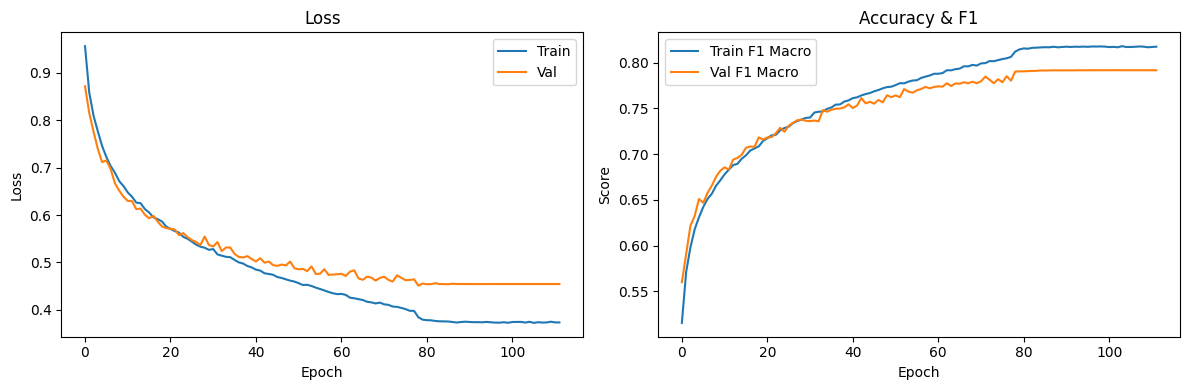

In [15]:
train_hist_df = pd.DataFrame(train_history)
val_hist_df = pd.DataFrame(val_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_hist_df.loss, label="Train")
ax1.plot(val_hist_df.loss, label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")

ax2.plot(train_hist_df.f1_macro, label="Train F1 Macro")
ax2.plot(val_hist_df.f1_macro, label="Val F1 Macro")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.legend()
ax2.set_title("Accuracy & F1")

plt.tight_layout()
plt.show()

## 4. Оценка на тесте

In [16]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
run_epoch(model, test_loader, criterion, device)

{'f1': 0.8552936911582947,
 'sensitivity': 0.9275642037391663,
 'ppv': 0.7934709191322327,
 'mcc': 0.6457107663154602,
 'f1_macro': 0.795828640460968,
 'loss': 0.44100738077199664}

## 5. Визуализация внимания



In [21]:
from contextlib import contextmanager

@contextmanager
def capture_attention(model):
    attention_weights = {}
    handles = []

    for i, layer in enumerate(model.encoder.layers):
        def make_pre_hook(idx):
            def hook(module, args, kwargs):
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = False
                return args, kwargs
            return hook

        def make_post_hook(idx):
            def hook(module, args, output):
                attention_weights[idx] = output[1].detach().cpu()
            return hook

        h1 = layer.self_attn.register_forward_pre_hook(make_pre_hook(i), with_kwargs=True)
        h2 = layer.self_attn.register_forward_hook(make_post_hook(i))
        handles.extend([h1, h2])

    try:
        yield attention_weights
    finally:
        for h in handles:
            h.remove()

Выбираем короткую последовательность (50–80 нт) с высокой долей спаренных позиций — на ней паттерны внимания будут наиболее читаемыми.

In [22]:
for i, sample in enumerate(test_ds):
    L = sample['length'].item()
    n_paired = (sample['labels'] != 0).sum().item()
    ratio = n_paired / L
    if 50 <= L <= 80 and ratio > 0.5:
        print(f"idx={i}  L={L}  paired={n_paired}  ratio={ratio:.2f}")

idx=0  L=75  paired=40  ratio=0.53
idx=2  L=72  paired=40  ratio=0.56
idx=12  L=78  paired=42  ratio=0.54
idx=39  L=75  paired=44  ratio=0.59
idx=46  L=76  paired=40  ratio=0.53
idx=62  L=71  paired=42  ratio=0.59
idx=64  L=74  paired=44  ratio=0.59
idx=68  L=76  paired=44  ratio=0.58
idx=71  L=75  paired=42  ratio=0.56
idx=80  L=67  paired=40  ratio=0.60
idx=104  L=76  paired=42  ratio=0.55
idx=116  L=76  paired=42  ratio=0.55
idx=118  L=76  paired=42  ratio=0.55
idx=120  L=76  paired=42  ratio=0.55
idx=124  L=76  paired=44  ratio=0.58
idx=138  L=78  paired=40  ratio=0.51
idx=151  L=76  paired=40  ratio=0.53
idx=168  L=77  paired=42  ratio=0.55
idx=178  L=73  paired=40  ratio=0.55
idx=182  L=76  paired=42  ratio=0.55
idx=201  L=75  paired=42  ratio=0.56
idx=205  L=78  paired=42  ratio=0.54
idx=209  L=75  paired=42  ratio=0.56
idx=225  L=77  paired=40  ratio=0.52
idx=231  L=76  paired=42  ratio=0.55
idx=235  L=76  paired=42  ratio=0.55
idx=236  L=77  paired=44  ratio=0.57
idx=246  L=75

Взял №27, так как модель предсказывает его на 100% правильно.

In [60]:
model.eval()
sample_idx = 270
sample = test_ds[sample_idx]
L = sample['length'].item()

tokens = sample['tokens'].unsqueeze(0).to(device)

with capture_attention(model) as attn_weights:
    with torch.no_grad():
        logits = model(tokens)

attn_0 = attn_weights[0][0, :, :L, :L]
attn_1 = attn_weights[1][0, :, :L, :L]
attn_2 = attn_weights[2][0, :, :L, :L]
attn_3 = attn_weights[3][0, :, :L, :L]
print(f'Длина последовательности: {L}')


Длина последовательности: 76


### 5.1 Карты внимания по головам (слой 0)

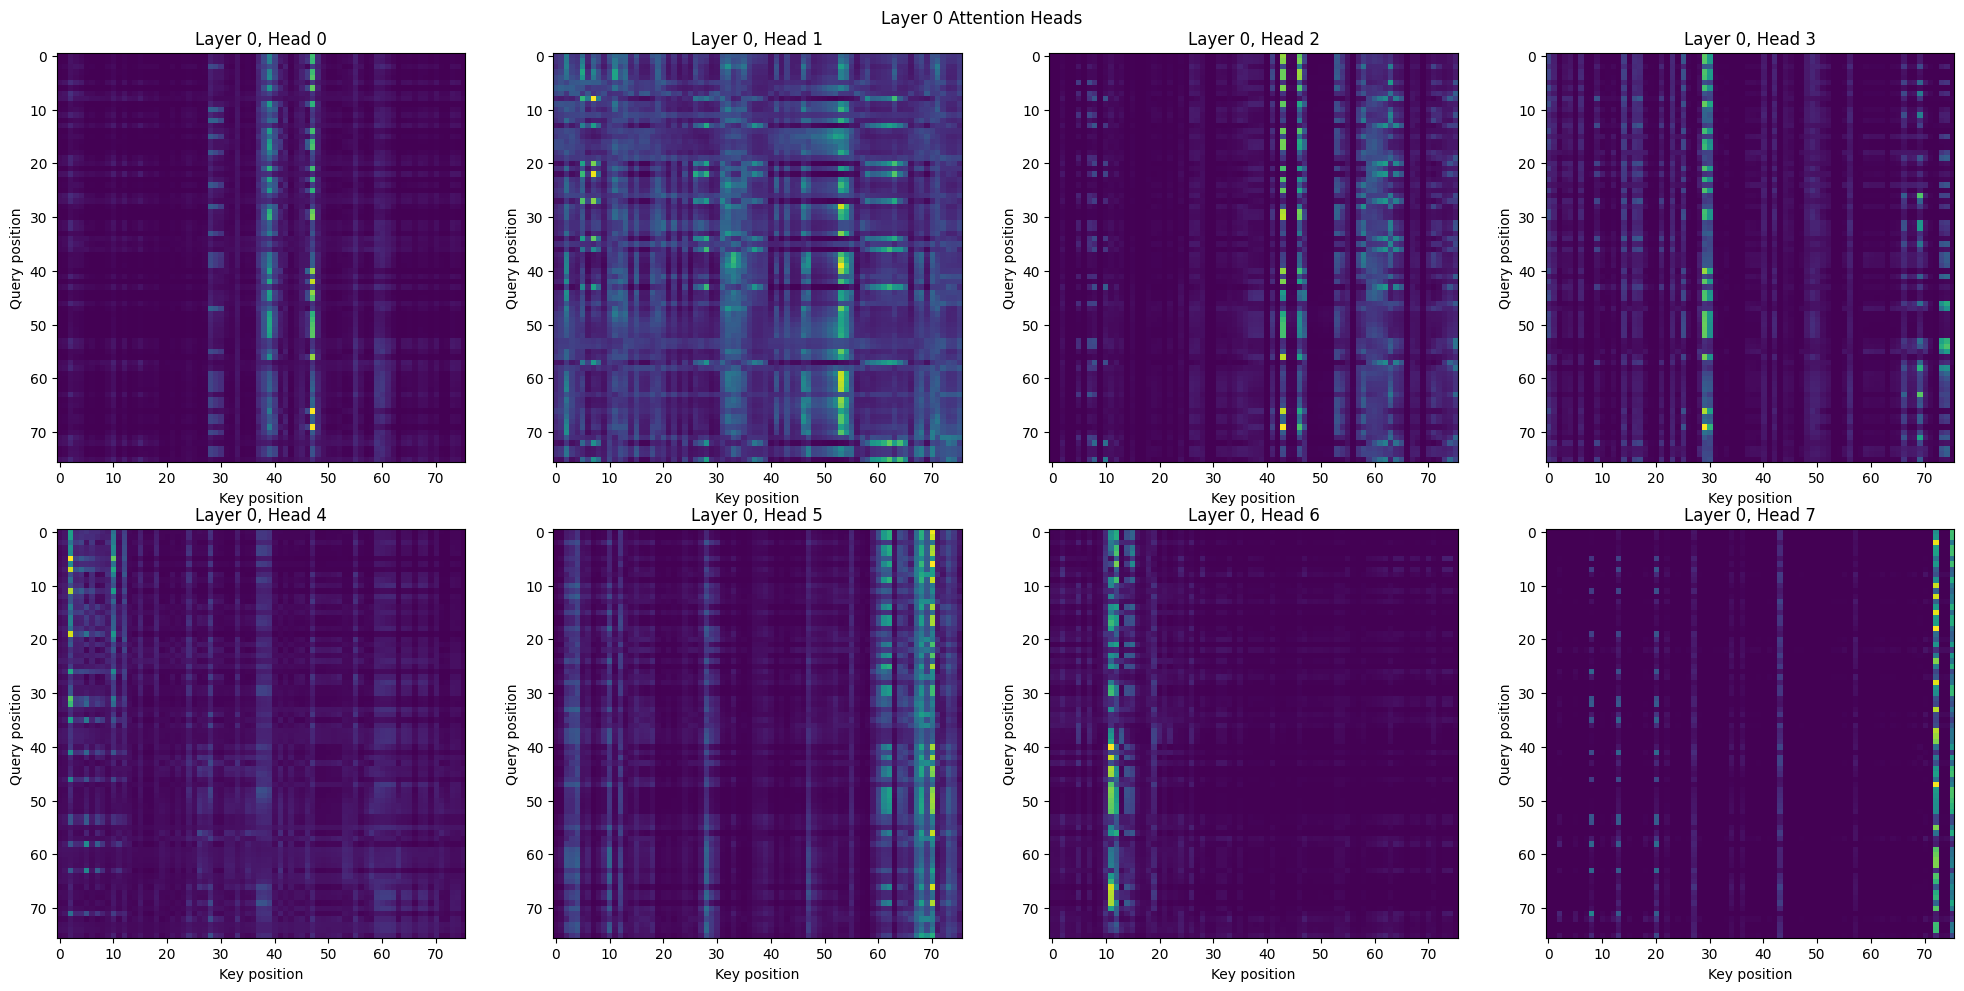

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for head_idx, ax in enumerate(axes.flat):
    ax.imshow(attn_0[head_idx].numpy(), cmap='viridis', aspect='equal')
    ax.set_title(f'Layer 0, Head {head_idx}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
plt.suptitle('Layer 0 Attention Heads')
plt.tight_layout()
plt.show()

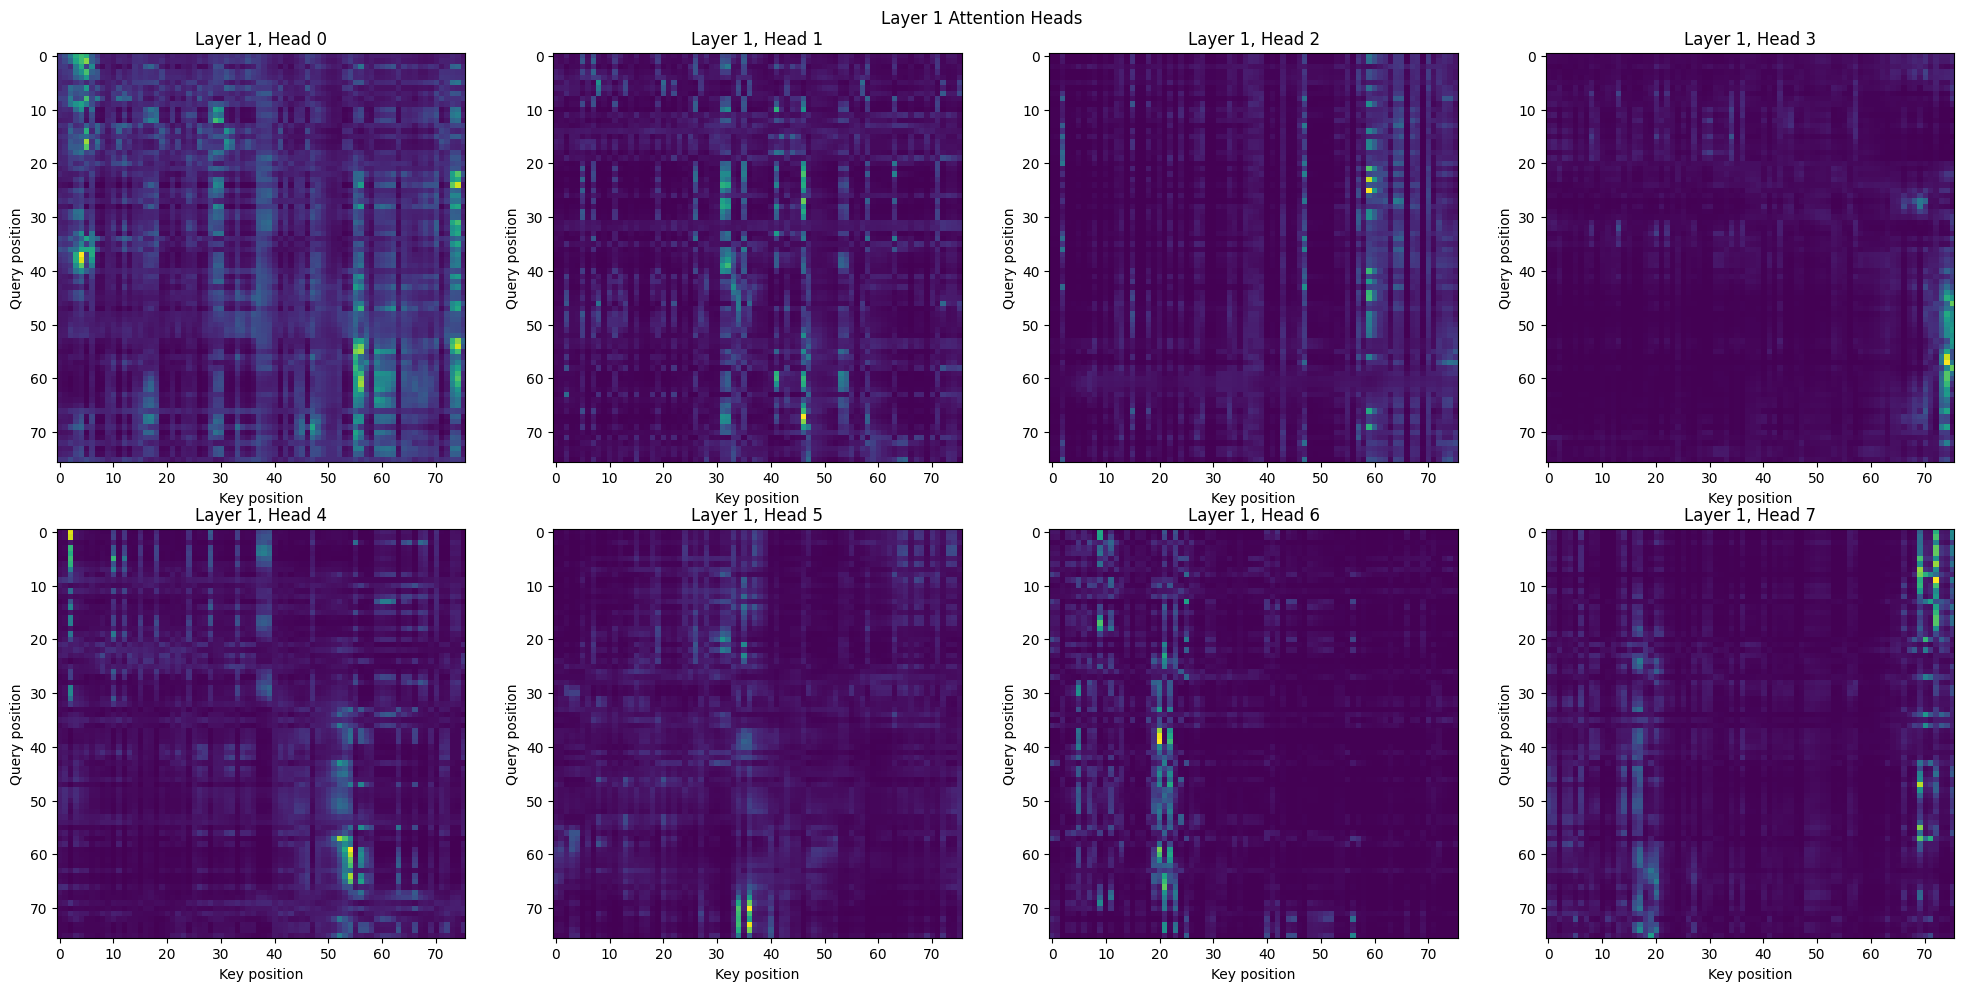

In [82]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for head_idx, ax in enumerate(axes.flat):
    ax.imshow(attn_1[head_idx].numpy(), cmap='viridis', aspect='equal')
    ax.set_title(f'Layer 1, Head {head_idx}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
plt.suptitle('Layer 1 Attention Heads')
plt.tight_layout()
plt.show()

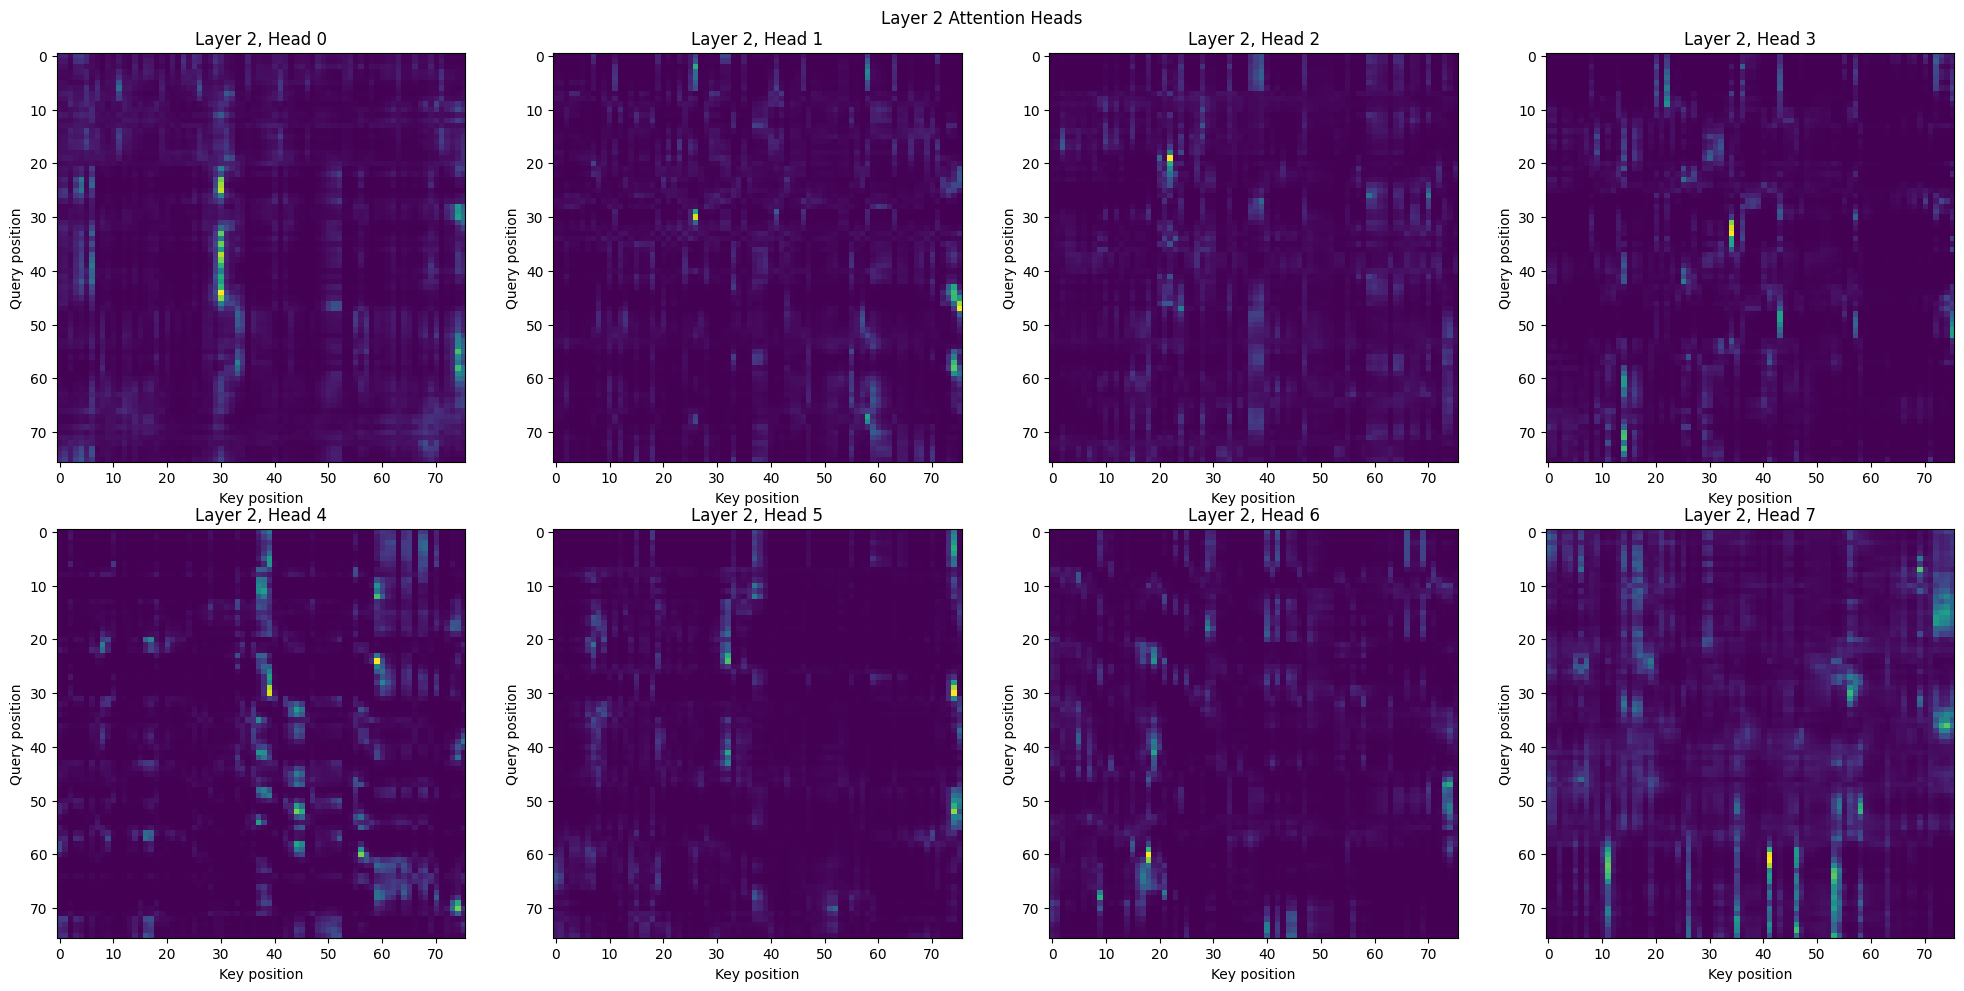

In [83]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for head_idx, ax in enumerate(axes.flat):
    ax.imshow(attn_2[head_idx].numpy(), cmap='viridis', aspect='equal')
    ax.set_title(f'Layer 2, Head {head_idx}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
plt.suptitle('Layer 2 Attention Heads')
plt.tight_layout()
plt.show()

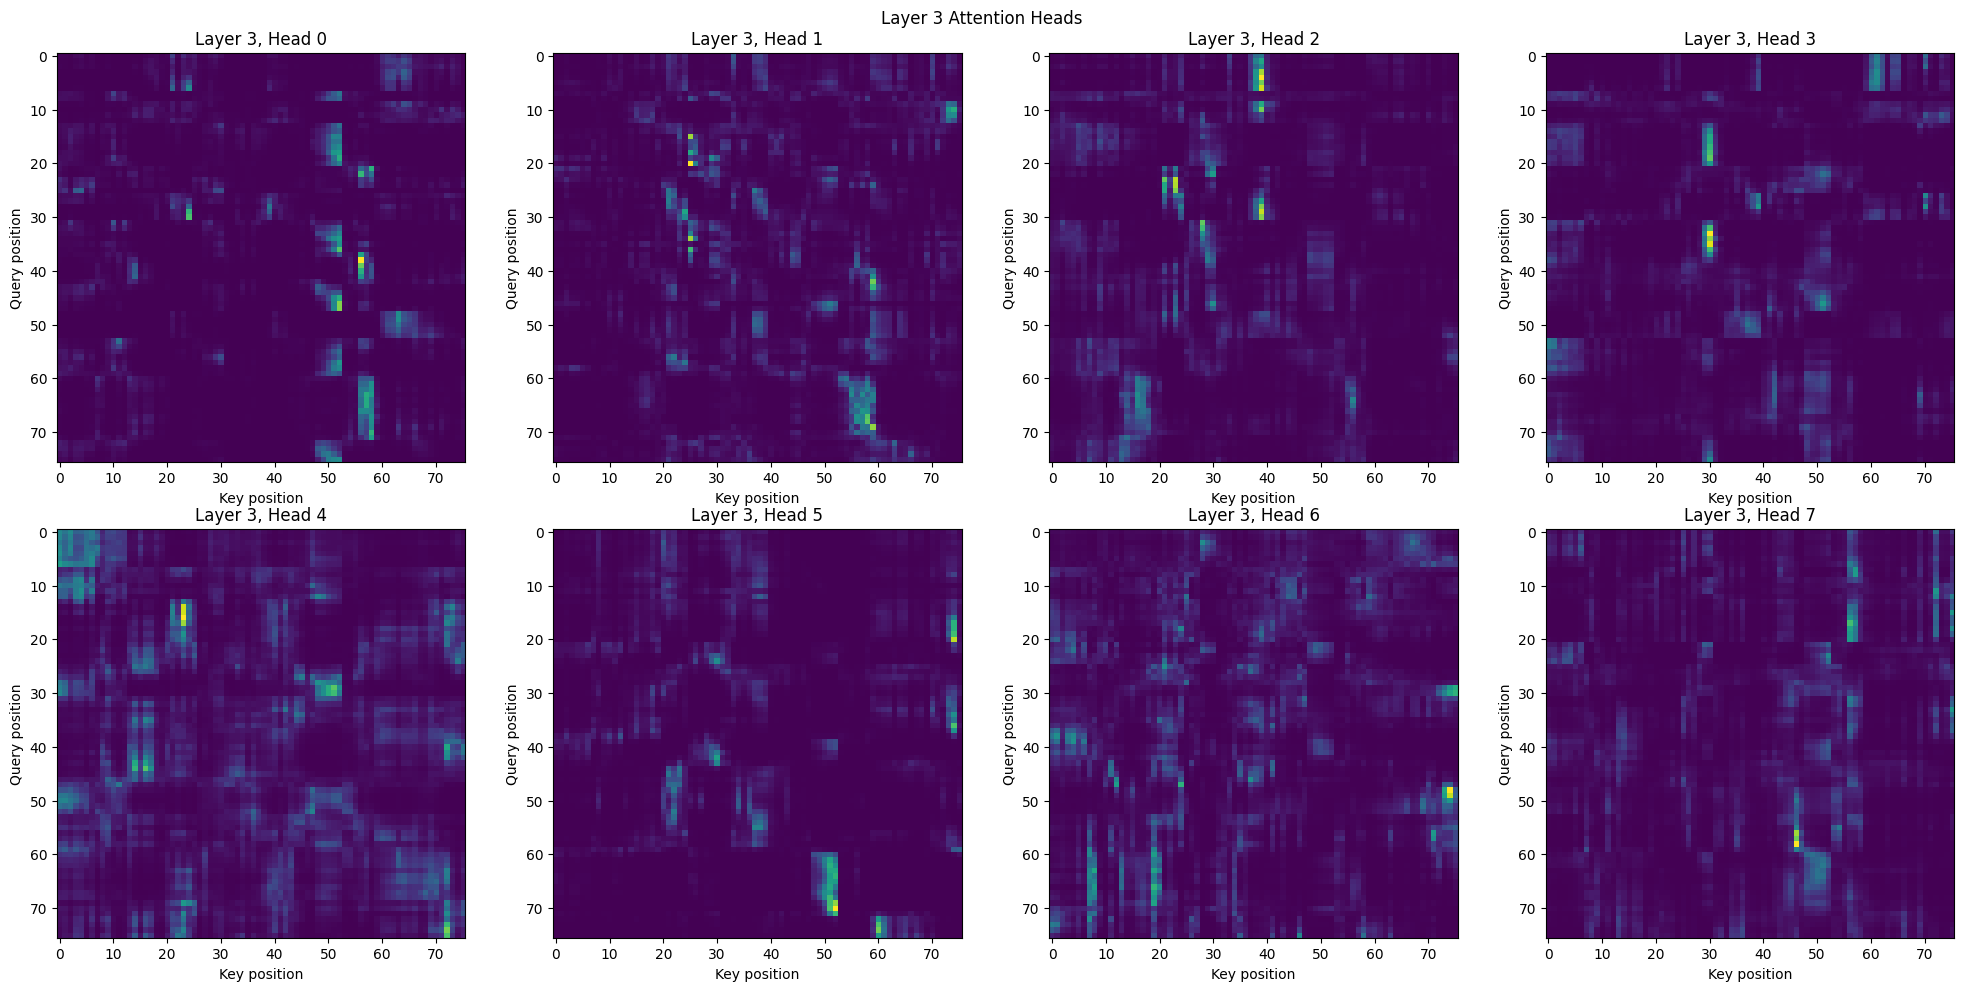

In [84]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for head_idx, ax in enumerate(axes.flat):
    ax.imshow(attn_3[head_idx].numpy(), cmap='viridis', aspect='equal')
    ax.set_title(f'Layer 3, Head {head_idx}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
plt.suptitle('Layer 3 Attention Heads')
plt.tight_layout()
plt.show()

### 5.2 Сравнение внимания с контактной картой

Контактная карта — бинарная матрица (L×L), где 1 означает спаривание нуклеотидов. Сравниваем её со средним вниманием слоя 0.

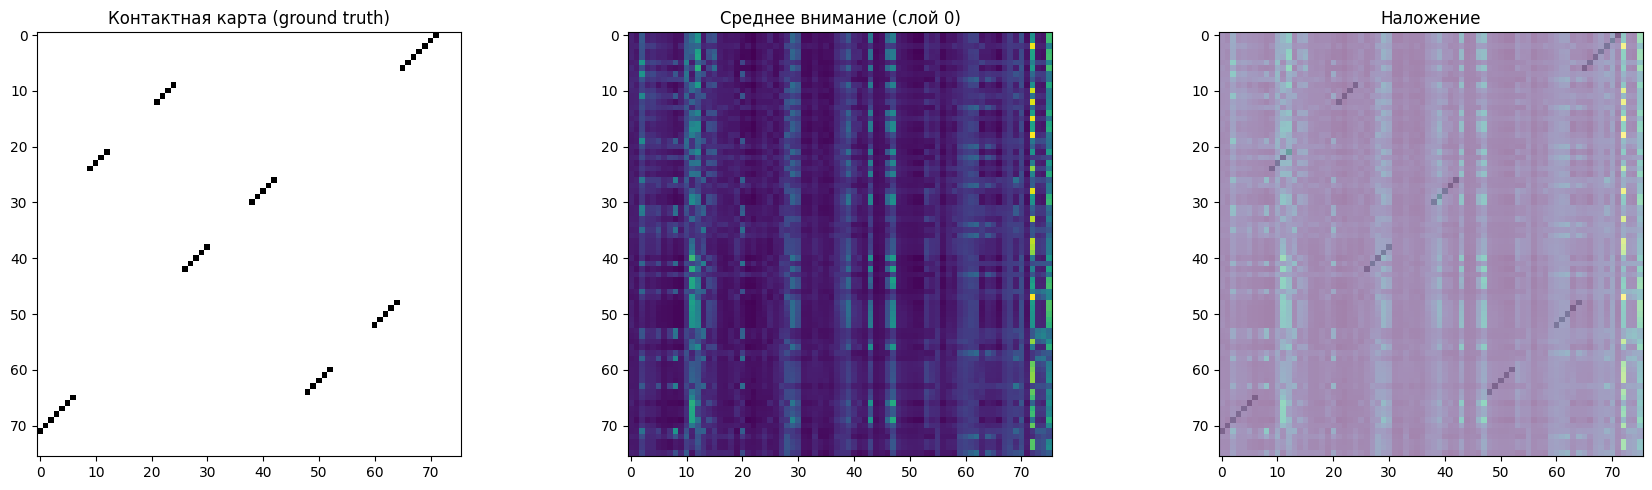

In [72]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]['secondary_structure']
test_ds.set_format('torch', columns=['tokens', 'labels', 'length'])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i-1, j-1] = contact[j-1, i-1] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(contact.numpy(), cmap='Greys')
axes[0].set_title('Контактная карта (ground truth)')

avg_attn = attn_0.mean(0).numpy()
axes[1].imshow(avg_attn, cmap='viridis')
axes[1].set_title('Среднее внимание (слой 0)')

axes[2].imshow(contact.numpy(), cmap='Greys', alpha=0.3)
axes[2].imshow(avg_attn, cmap='viridis', alpha=0.5)
axes[2].set_title('Наложение')
plt.tight_layout()
plt.show()


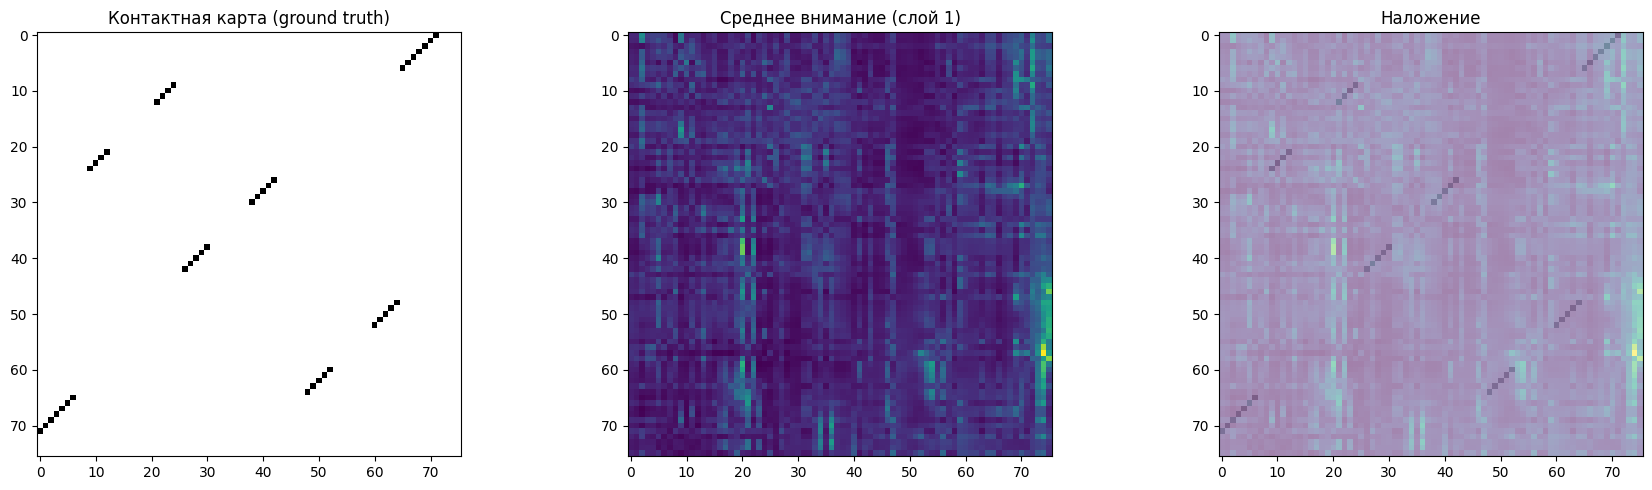

In [79]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]['secondary_structure']
test_ds.set_format('torch', columns=['tokens', 'labels', 'length'])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i-1, j-1] = contact[j-1, i-1] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(contact.numpy(), cmap='Greys')
axes[0].set_title('Контактная карта (ground truth)')

avg_attn = attn_1.mean(0).numpy()
axes[1].imshow(avg_attn, cmap='viridis')
axes[1].set_title('Среднее внимание (слой 1)')

axes[2].imshow(contact.numpy(), cmap='Greys', alpha=0.3)
axes[2].imshow(avg_attn, cmap='viridis', alpha=0.5)
axes[2].set_title('Наложение')
plt.tight_layout()
plt.show()

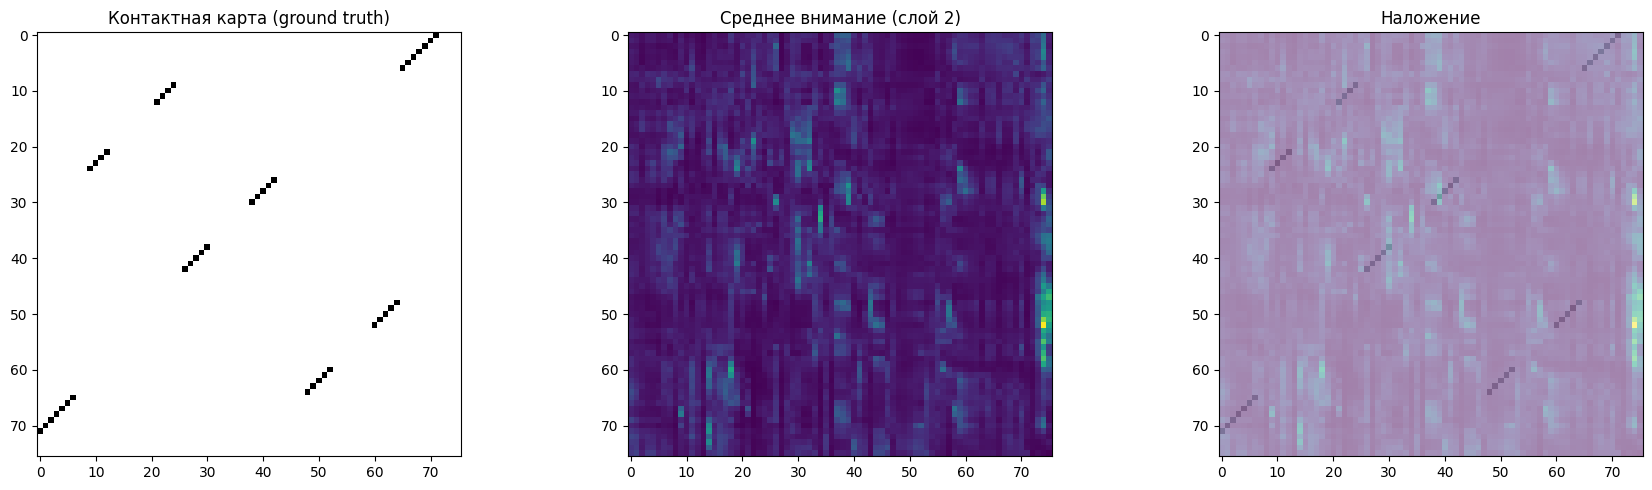

In [80]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]['secondary_structure']
test_ds.set_format('torch', columns=['tokens', 'labels', 'length'])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i-1, j-1] = contact[j-1, i-1] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(contact.numpy(), cmap='Greys')
axes[0].set_title('Контактная карта (ground truth)')

avg_attn = attn_2.mean(0).numpy()
axes[1].imshow(avg_attn, cmap='viridis')
axes[1].set_title('Среднее внимание (слой 2)')

axes[2].imshow(contact.numpy(), cmap='Greys', alpha=0.3)
axes[2].imshow(avg_attn, cmap='viridis', alpha=0.5)
axes[2].set_title('Наложение')
plt.tight_layout()
plt.show()

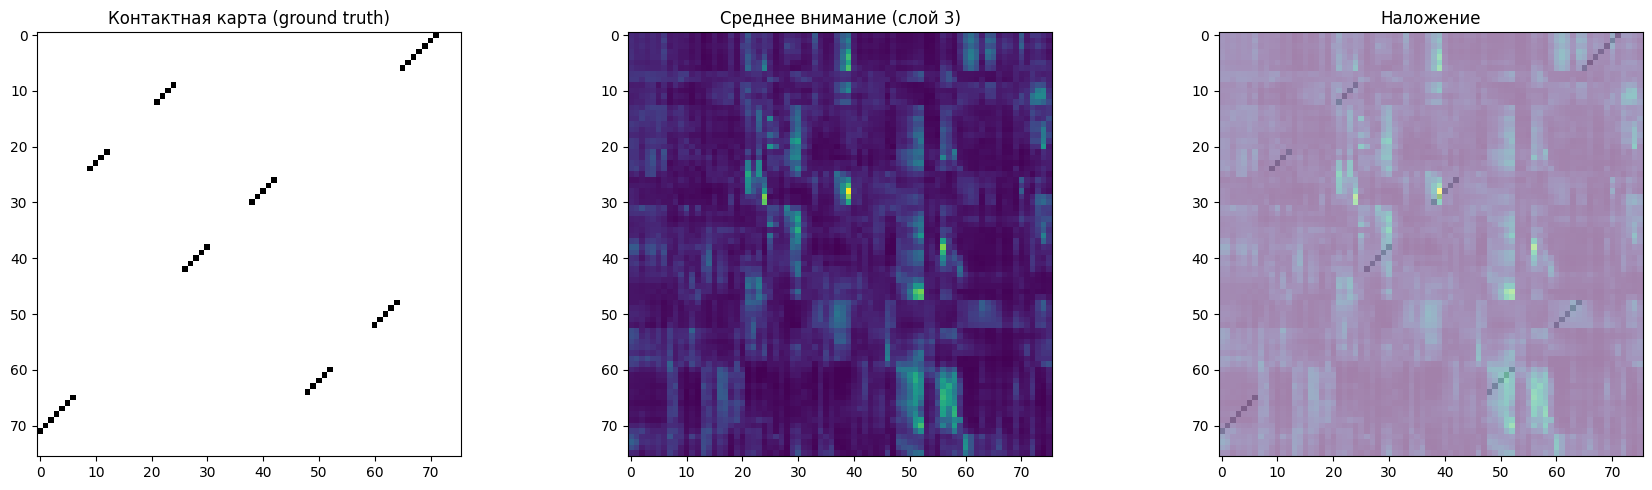

In [81]:
test_ds.reset_format()
secondary_structure = test_ds[sample_idx]['secondary_structure']
test_ds.set_format('torch', columns=['tokens', 'labels', 'length'])

pairs = dot_bracket_to_pairs(secondary_structure)
contact = torch.zeros(L, L)
for i, j in pairs:
    if 1 <= i <= L and 1 <= j <= L:
        contact[i-1, j-1] = contact[j-1, i-1] = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(contact.numpy(), cmap='Greys')
axes[0].set_title('Контактная карта (ground truth)')

avg_attn = attn_3.mean(0).numpy()
axes[1].imshow(avg_attn, cmap='viridis')
axes[1].set_title('Среднее внимание (слой 3)')

axes[2].imshow(contact.numpy(), cmap='Greys', alpha=0.3)
axes[2].imshow(avg_attn, cmap='viridis', alpha=0.5)
axes[2].set_title('Наложение')
plt.tight_layout()
plt.show()

### 5.3 Профиль внимания по расстоянию

Среднее внимание в зависимости от расстояния между позициями — показывает, какие головы фокусируются на ближних соседях (стэкинг), а какие — на дальних парах.

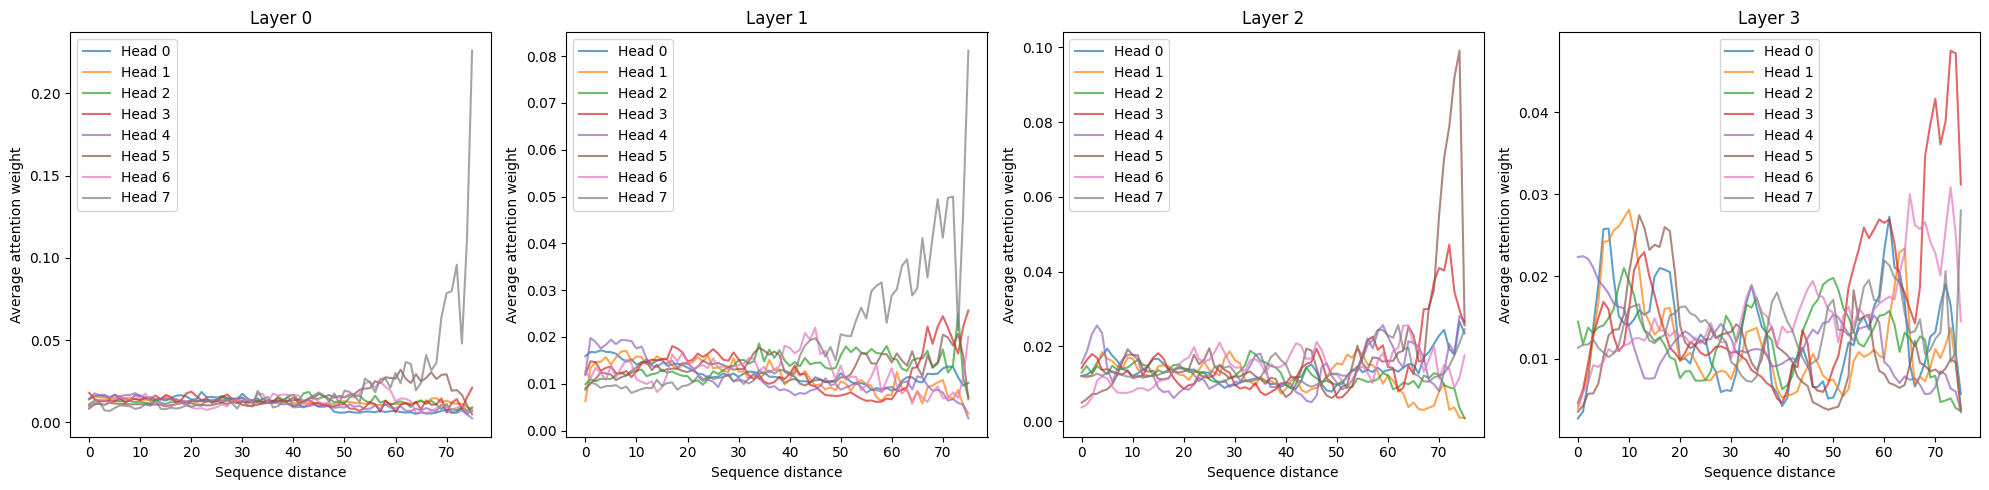

In [77]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for layer_idx, attn in [(0, attn_0), (1, attn_1), (2, attn_2), (3, attn_3)]:
    for head_idx in range(attn.size(0)):
        distances = []
        weights = []
        for i in range(L):
            for j in range(L):
                distances.append(abs(i - j))
                weights.append(attn[head_idx, i, j].item())
        # Bin by distance
        max_dist = max(distances)
        bins = np.zeros(max_dist + 1)
        counts = np.zeros(max_dist + 1)
        for d, w in zip(distances, weights):
            bins[d] += w
            counts[d] += 1
        avg_weight = bins / (counts + 1e-8)
        axes[layer_idx].plot(avg_weight[:100], label=f'Head {head_idx}', alpha=0.7)
    axes[layer_idx].set_xlabel('Sequence distance')
    axes[layer_idx].set_ylabel('Average attention weight')
    axes[layer_idx].set_title(f'Layer {layer_idx}')
    axes[layer_idx].legend()
plt.tight_layout()
plt.show()

### 5.4 Предсказание vs ground truth

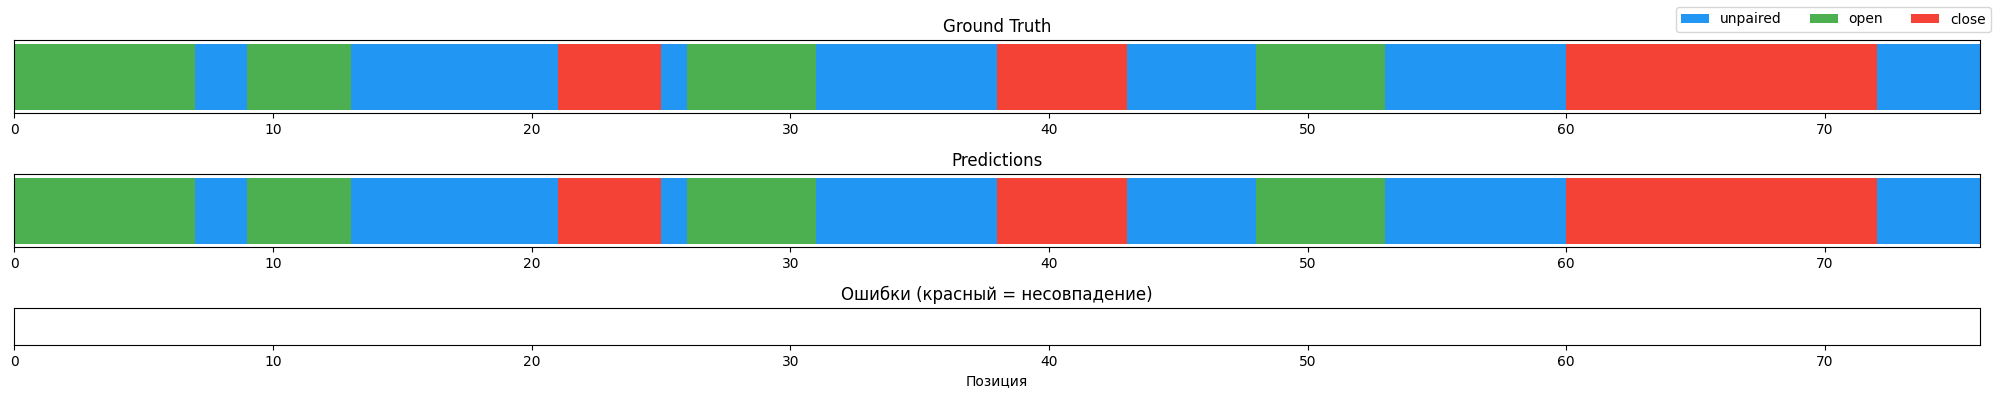

Per-position accuracy: 100.00% (76/76)


In [59]:
sample = test_ds[sample_idx]
tokens = sample['tokens'].unsqueeze(0).to(device)
L = sample['length'].item()

with torch.no_grad():
    logits = model(tokens)
preds = logits.argmax(1).squeeze().cpu()[:L].numpy()
labels = sample['labels'][:L].numpy()

label_names = {0: 'unpaired', 1: 'open', 2: 'close'}
colors = {0: '#2196F3', 1: '#4CAF50', 2: '#F44336'}

fig, axes = plt.subplots(3, 1, figsize=(20, 4), gridspec_kw={'height_ratios': [1, 1, 0.5]})

for i in range(L):
    axes[0].barh(0, 1, left=i, color=colors[labels[i]], edgecolor='none')
axes[0].set_xlim(0, L); axes[0].set_yticks([]); axes[0].set_title('Ground Truth')

for i in range(L):
    axes[1].barh(0, 1, left=i, color=colors[preds[i]], edgecolor='none')
axes[1].set_xlim(0, L); axes[1].set_yticks([]); axes[1].set_title('Predictions')

for i in range(L):
    axes[2].barh(0, 1, left=i, color='red' if preds[i] != labels[i] else 'white', edgecolor='none')
axes[2].set_xlim(0, L); axes[2].set_yticks([])
axes[2].set_title('Ошибки (красный = несовпадение)')
axes[2].set_xlabel('Позиция')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=v) for k, v in label_names.items()]
fig.legend(handles=legend_elements, loc='upper right', ncol=3)
plt.tight_layout()
plt.show()

acc = (preds == labels).mean()
print(f'Per-position accuracy: {acc:.2%} ({(preds == labels).sum()}/{L})')


## 6. Выводы

Можно заметить, что на слоях 0-1 головы имеют более рассеянное внимание.
Причем, некоторые головы сфоркусированы на начале последовательности (5'), на конце (3') и на середине.

Для последних двух слоев характерно более сфокусированное внимание, причем елси посмотреть на 7 голову 2 слоя, то можно заметить столбцы рядом с регионами, которые маркируются, как взаимодействующие. Но на матрицу взаимодействия лучше всего накладывается слой 3.

Графики сделаны с помощью llm